/opt/homebrew/opt/python@3.11/bin/python3.11
⏳ Lade CSV … (kann etwas dauern)
✅ Geladen: 4,501,357 Zeilen  |  21 Spalten

1. GRUNDLEGENDE INFOS
code                       object
creator                       str
created_datetime              str
last_modified_datetime        str
product_name                  str
packaging_en                  str
categories_en                 str
labels_en                     str
countries_en                  str
ingredients_text              str
nutriscore_score              str
nutriscore_grade              str
nova_group                    str
completeness                  str
energy-kcal_100g          float64
fat_100g                      str
saturated-fat_100g            str
sugars_100g               float64
fiber_100g                float64
proteins_100g             float64
salt_100g                 float64
dtype: object

                            count     unique                   top  \
code                    4501357.0  4501291.0             

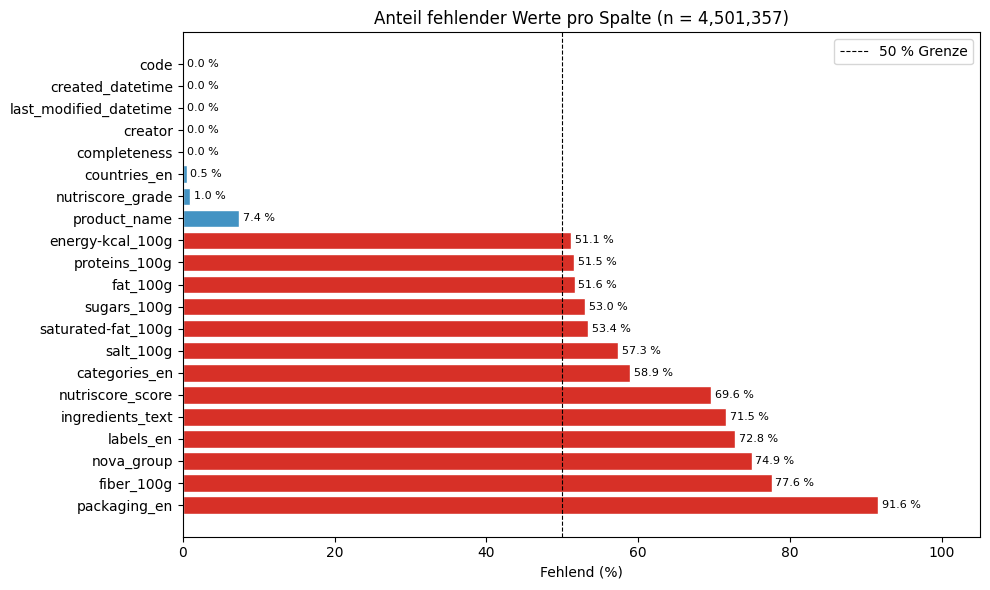

→ Grafik gespeichert: missing_values.png

3. NUTRI-SCORE VERTEILUNG
nutriscore_grade
A    199848
B    157730
C    283906
D    343253
E    383481

Produkte MIT Nutri-Score:  1,368,218 (30.4 %)
Produkte OHNE Nutri-Score: 44,847


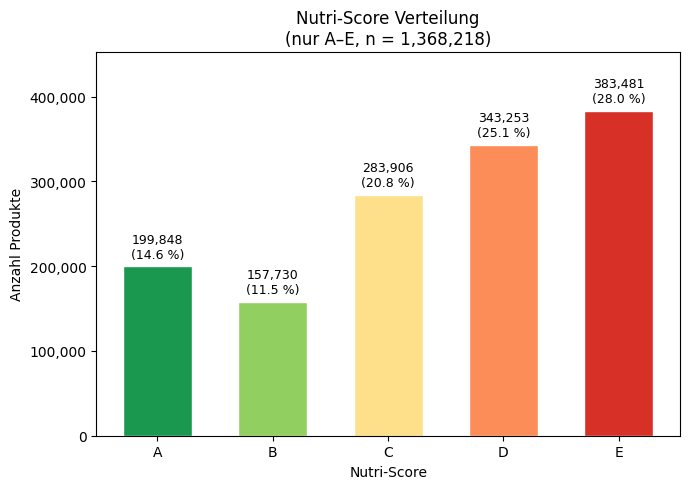


4. NOVA-GRUPPE (Verarbeitungsgrad)
nova_group
1 – Unverarbeitet           134427
2 – Verarbeitete Zutaten     65184
3 – Verarbeitet             209063
4 – Ultra-verarbeitet       720379


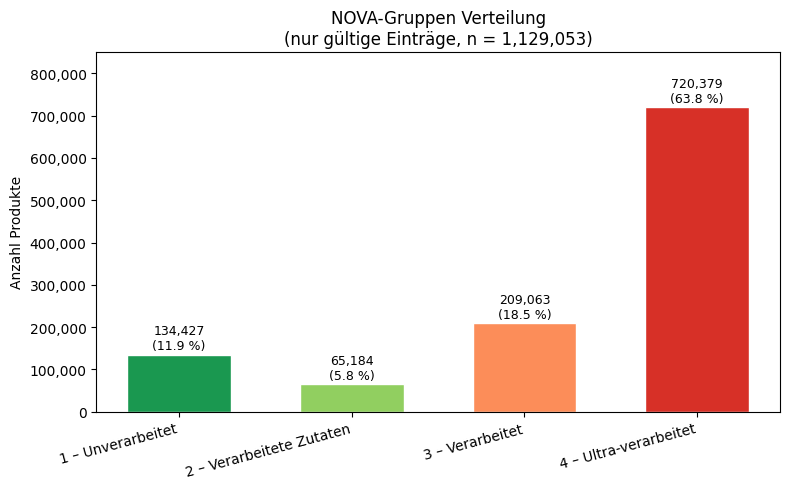


5. TOP 20 LÄNDER (nach Produktanzahl)
countries_en
France            1256585
United States      901610
Germany            405552
Spain              353473
Italy              265797
United Kingdom     184992
Canada             119574
Switzerland        103083
Belgium            100200
Ireland             78491
Netherlands         74949
World               73900
Australia           72601
Japan               38531
Romania             35858
Poland              34162
Russia              34075
Brazil              33802
Norway              25295
Sweden              24732


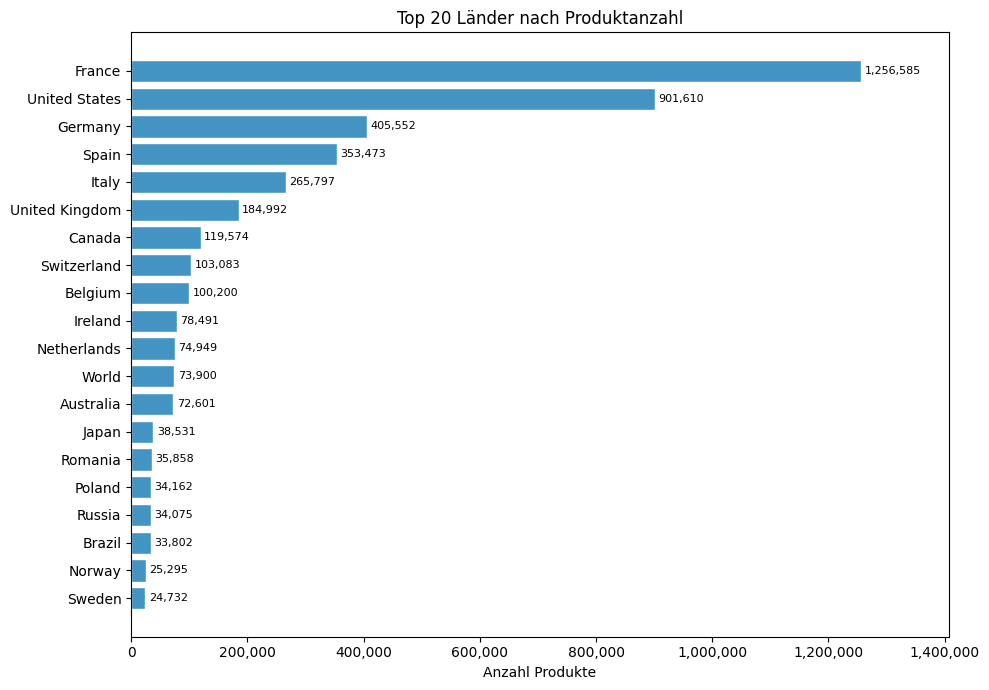


6. NÄHRWERTE – ÜBERBLICK (pro 100g)
       energy-kcal_100g     fat_100g  saturated-fat_100g   sugars_100g   fiber_100g  proteins_100g     salt_100g
count      2.201195e+06   2177811.00          2099429.00  2.114518e+06   1010215.00   2.181475e+06  1.922304e+06
mean       6.465896e+09        22.26                5.48  5.555486e+26        13.56   1.704730e+03  1.163700e+02
std        9.593077e+12     11904.18              407.59  8.078444e+29      9952.70   1.840637e+06  1.583307e+05
min       -1.138600e+02        -0.00               -3.99 -9.000000e-02        -3.33  -4.760000e+00 -4.500000e-01
25%        1.090000e+02         1.17                0.20  6.000000e-01         0.16   2.000000e+00  1.000000e-01
50%        2.533300e+02         7.30                1.90  3.200000e+00         1.67   6.700000e+00  5.700000e-01
75%        3.940000e+02        21.00                7.00  1.440000e+01         3.90   1.400000e+01  1.400000e+00
max        1.423270e+16  17554003.53           588000.00  1

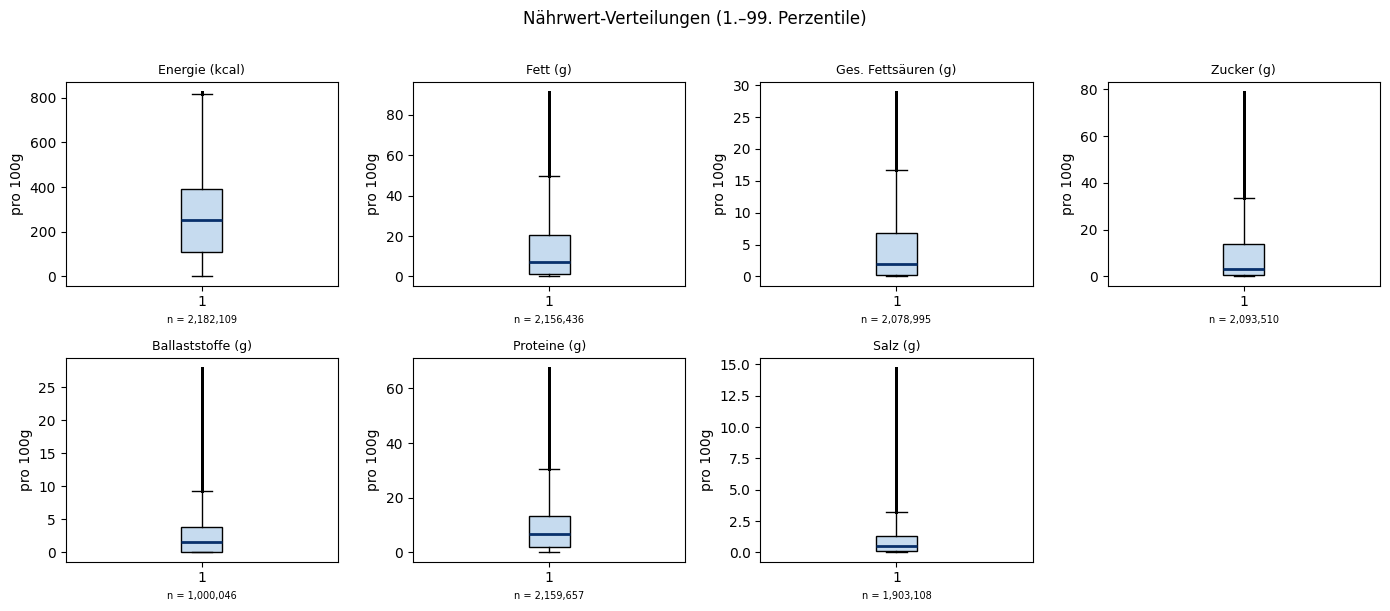


7. ZEITLICHE ENTWICKLUNG (Einträge pro Jahr)
year_created
2012      4397
2013      9883
2014     13209
2015     34774
2016     45713
2017    283004
2018    323478
2019    366273
2020    466602
2021    512285
2022    595980
2023    356801
2024    547686
2025    673789


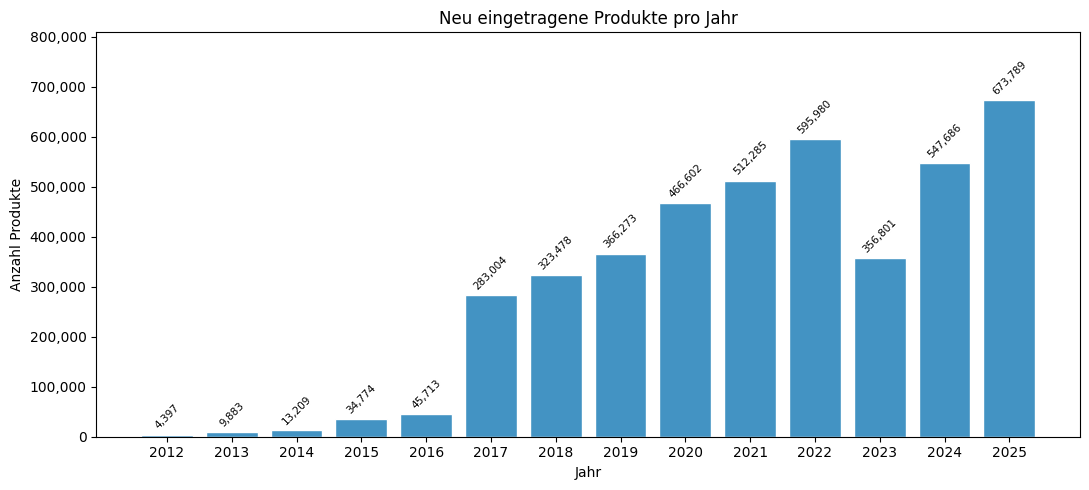


8. VOLLSTÄNDIGKEIT DER EINTRÄGE
count    4501302.000
mean           0.417
std            0.205
min            0.050
25%            0.275
50%            0.375
75%            0.500
max            1.100
Name: completeness, dtype: float64


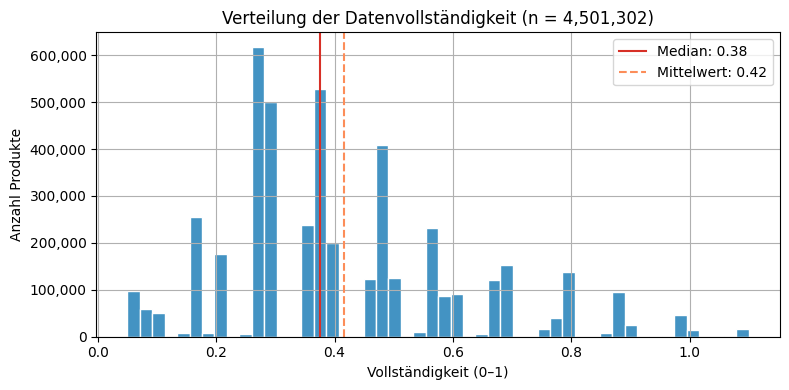


9. ZUSAMMENFASSUNG FÜR MEILENSTEIN 1
Gesamtprodukte:             4,501,357
Produkte mit Name:          4,166,212  (92.6 %)
Produkte mit Nutri-Score:   4,456,510  (99.0 %)
Produkte mit NOVA-Gruppe:   1,129,056  (25.1 %)
Produkte mit Land:          4,478,367  (99.5 %)
Produkte mit Nährwerten:    2,201,195  (48.9 %)
Jahresspanne:            2012 – 2026

Alle Grafiken wurden als PNG gespeichert.
Viel Erfolg beim Meilenstein 1! 🚀


In [1]:
# ============================================================
#  Open Food Facts – Erster Überblick
#  Einfach in ein Jupyter Notebook kopieren und Zelle für Zelle ausführen
# ============================================================
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── 0. DATEI LADEN ───────────────────────────────────────────
# Pfad anpassen!
CSV_PATH = "en.openfoodfacts.org.products 2.csv"

# Wir laden zunächst nur die wichtigsten Spalten –
# die volle Datei hat >180 Spalten und mehrere GB.
COLS = [
    "code", "product_name", "countries_en",
    "categories_en", "labels_en",
    "packaging_en",
    "nutriscore_grade", "nutriscore_score",
    "nova_group", "ecoscore_grade",
    "energy-kcal_100g", "fat_100g", "saturated-fat_100g",
    "sugars_100g", "fiber_100g", "proteins_100g", "salt_100g",
    "ingredients_text",
    "created_datetime", "last_modified_datetime",
    "creator", "completeness",
]

print("⏳ Lade CSV … (kann etwas dauern)")
df = pd.read_csv(
    CSV_PATH,
    sep="\t",           # Open Food Facts nutzt Tab als Trennzeichen
    usecols=lambda c: c in COLS,
    low_memory=False,
    on_bad_lines="skip",
)
print(f"✅ Geladen: {df.shape[0]:,} Zeilen  |  {df.shape[1]} Spalten\n")


# ── 1. GRUNDLEGENDE INFOS ────────────────────────────────────
print("=" * 55)
print("1. GRUNDLEGENDE INFOS")
print("=" * 55)
print(df.dtypes)
print()
print(df.describe(include="all").T.reindex(columns=["count","unique","top","mean","std","min","max"]))


# ── 2. FEHLENDE WERTE ────────────────────────────────────────
print("\n" + "=" * 55)
print("2. FEHLENDE WERTE (% der Zeilen)")
print("=" * 55)
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing.to_string())

# Visualisierung fehlender Werte
colors_mv = ["#d73027" if v > 50 else "#4393c3" for v in missing]
fig, ax = plt.subplots(figsize=(10, 6))
bars_mv = ax.barh(missing.index, missing.values, color=colors_mv, edgecolor="white")
for bar, val in zip(bars_mv, missing.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} %", va="center", fontsize=8)
ax.set_xlabel("Fehlend (%)")
ax.set_title(f"Anteil fehlender Werte pro Spalte (n = {len(df):,})")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50 % Grenze")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig("missing_values.png", dpi=150)
plt.show()
print("→ Grafik gespeichert: missing_values.png")


# ── 3. NUTRI-SCORE VERTEILUNG ────────────────────────────────
print("\n" + "=" * 55)
print("3. NUTRI-SCORE VERTEILUNG")
print("=" * 55)
ns = (df["nutriscore_grade"].str.upper()
      .where(lambda x: x.isin(["A","B","C","D","E"]))
      .value_counts().reindex(["A","B","C","D","E"]))
print(ns.to_string())
print(f"\nProdukte MIT Nutri-Score:  {ns.sum():,} ({ns.sum()/len(df)*100:.1f} %)")
print(f"Produkte OHNE Nutri-Score: {df['nutriscore_grade'].isna().sum():,}")

colors_ns = ["#1a9850","#91cf60","#fee08b","#fc8d59","#d73027"]
total_ns = ns.sum()
fig, ax = plt.subplots(figsize=(7, 5))
bars_ns = ax.bar(ns.index, ns.values, color=colors_ns, edgecolor="white", width=0.6)
for bar, count in zip(bars_ns, ns.values):
    pct = count / total_ns * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total_ns * 0.005,
            f"{count:,}\n({pct:.1f} %)", ha="center", va="bottom", fontsize=9)
ax.set_title(f"Nutri-Score Verteilung\n(nur A–E, n = {total_ns:,})", fontsize=12)
ax.set_xlabel("Nutri-Score")
ax.set_ylabel("Anzahl Produkte")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, ns.max() * 1.18)
plt.tight_layout()
plt.savefig("nutriscore_distribution.png", dpi=150)
plt.show()


# ── 4. NOVA-GRUPPE ───────────────────────────────────────────
print("\n" + "=" * 55)
print("4. NOVA-GRUPPE (Verarbeitungsgrad)")
print("=" * 55)
nova_raw = pd.to_numeric(df["nova_group"], errors="coerce")
nova = nova_raw[nova_raw.isin([1, 2, 3, 4])].value_counts().sort_index()
print(nova.rename({1:"1 – Unverarbeitet", 2:"2 – Verarbeitete Zutaten",
                   3:"3 – Verarbeitet", 4:"4 – Ultra-verarbeitet"}).to_string())

labels_nova = {1:"1 – Unverarbeitet", 2:"2 – Verarbeitete Zutaten",
               3:"3 – Verarbeitet", 4:"4 – Ultra-verarbeitet"}
colors_nova = ["#1a9850", "#91cf60", "#fc8d59", "#d73027"]
total_nova = nova.sum()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [labels_nova[i] for i in nova.index],
    nova.values,
    color=colors_nova,
    edgecolor="white",
    width=0.6,
)
for bar, count in zip(bars, nova.values):
    pct = count / total_nova * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total_nova * 0.005,
        f"{count:,}\n({pct:.1f} %)",
        ha="center", va="bottom", fontsize=9,
    )
ax.set_title(f"NOVA-Gruppen Verteilung\n(nur gültige Einträge, n = {total_nova:,})", fontsize=12)
ax.set_ylabel("Anzahl Produkte")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, nova.max() * 1.18)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("nova_distribution.png", dpi=150)
plt.show()


# ── 5. TOP-LÄNDER ────────────────────────────────────────────
print("\n" + "=" * 55)
print("5. TOP 20 LÄNDER (nach Produktanzahl)")
print("=" * 55)
top_countries = (
    df["countries_en"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(20)
)
print(top_countries.to_string())

top_sorted = top_countries.sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
bars_tc = ax.barh(top_sorted.index, top_sorted.values, color="#4393c3", edgecolor="white")
for bar, val in zip(bars_tc, top_sorted.values):
    ax.text(val + top_sorted.max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8)
ax.set_title("Top 20 Länder nach Produktanzahl")
ax.set_xlabel("Anzahl Produkte")
ax.set_xlim(0, top_sorted.max() * 1.12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("top_countries.png", dpi=150)
plt.show()


# ── 6. NÄHRWERTE – ÜBERBLICK ─────────────────────────────────
print("\n" + "=" * 55)
print("6. NÄHRWERTE – ÜBERBLICK (pro 100g)")
print("=" * 55)
nutrients = ["energy-kcal_100g","fat_100g","saturated-fat_100g",
             "sugars_100g","fiber_100g","proteins_100g","salt_100g"]

# Spalten zu Zahlen konvertieren (fehlerhafte Werte werden NaN)
for col in nutrients:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[nutrients].describe().round(2).to_string())

nice_names = ["Energie (kcal)","Fett (g)","Ges. Fettsäuren (g)",
              "Zucker (g)","Ballaststoffe (g)","Proteine (g)","Salz (g)"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, (col, name) in enumerate(zip(nutrients, nice_names)):
    data = df[col].dropna()
    q1, q99 = data.quantile(0.01), data.quantile(0.99)
    clipped = data[(data >= q1) & (data <= q99)]
    axes[i].boxplot(clipped, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#c6dbef"),
                    medianprops=dict(color="#08306b", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    axes[i].set_title(name, fontsize=9)
    axes[i].set_ylabel("pro 100g")
    axes[i].set_xlabel(f"n = {len(clipped):,}", fontsize=7)
axes[-1].axis("off")
plt.suptitle("Nährwert-Verteilungen (1.–99. Perzentile)", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("nutrients_boxplot.png", dpi=150)
plt.show()


# ── 7. ZEITLICHE ENTWICKLUNG ─────────────────────────────────
print("\n" + "=" * 55)
print("7. ZEITLICHE ENTWICKLUNG (Einträge pro Jahr)")
print("=" * 55)
df["year_created"] = pd.to_datetime(
    df["created_datetime"], errors="coerce"
).dt.year
yearly = df["year_created"].value_counts().sort_index()
yearly = yearly[(yearly.index >= 2012) & (yearly.index <= 2025)]
print(yearly.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
bars_yr = ax.bar(yearly.index.astype(str), yearly.values, color="#4393c3", edgecolor="white")
for bar, val in zip(bars_yr, yearly.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + yearly.max() * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=7.5, rotation=45)
ax.set_title("Neu eingetragene Produkte pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl Produkte")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, yearly.max() * 1.2)
plt.tight_layout()
plt.savefig("yearly_entries.png", dpi=150)
plt.show()


# ── 8. VOLLSTÄNDIGKEIT ───────────────────────────────────────
print("\n" + "=" * 55)
print("8. VOLLSTÄNDIGKEIT DER EINTRÄGE")
print("=" * 55)
if "completeness" in df.columns:
    df["completeness"] = pd.to_numeric(df["completeness"], errors="coerce")
    print(df["completeness"].describe().round(3))
    comp = df["completeness"].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    comp.hist(bins=50, ax=ax, color="#4393c3", edgecolor="white")
    ax.axvline(comp.median(), color="#d73027", linewidth=1.5,
               label=f"Median: {comp.median():.2f}")
    ax.axvline(comp.mean(), color="#fc8d59", linewidth=1.5, linestyle="--",
               label=f"Mittelwert: {comp.mean():.2f}")
    ax.set_title(f"Verteilung der Datenvollständigkeit (n = {len(comp):,})")
    ax.set_xlabel("Vollständigkeit (0–1)")
    ax.set_ylabel("Anzahl Produkte")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend()
    plt.tight_layout()
    plt.savefig("completeness.png", dpi=150)
    plt.show()


# ── 9. KURZE ZUSAMMENFASSUNG ─────────────────────────────────
print("\n" + "=" * 55)
print("9. ZUSAMMENFASSUNG FÜR MEILENSTEIN 1")
print("=" * 55)
print(f"Gesamtprodukte:          {len(df):>12,}")
print(f"Produkte mit Name:       {df['product_name'].notna().sum():>12,}  ({df['product_name'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Nutri-Score:{df['nutriscore_grade'].notna().sum():>12,}  ({df['nutriscore_grade'].notna().mean()*100:.1f} %)")
print(f"Produkte mit NOVA-Gruppe:{df['nova_group'].notna().sum():>12,}  ({df['nova_group'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Land:       {df['countries_en'].notna().sum():>12,}  ({df['countries_en'].notna().mean()*100:.1f} %)")
print(f"Produkte mit Nährwerten: {df['energy-kcal_100g'].notna().sum():>12,}  ({df['energy-kcal_100g'].notna().mean()*100:.1f} %)")
print(f"Jahresspanne:            {int(df['year_created'].min())} – {int(df['year_created'].max())}")
print()
print("Alle Grafiken wurden als PNG gespeichert.")
print("Viel Erfolg beim Meilenstein 1! 🚀")

⏳ Lade CSV mit wichtigen Spalten …
✅ Geladen: 4,501,357 Zeilen  |  34 Spalten

Fehlende Werte pro Spalte:
  code                                  0.0%  (0 fehlend)
  states_en                             0.0%  (6 fehlend)
  completeness                          0.0%  (54 fehlend)
  countries_en                          0.5%  (22,990 fehlend)
  pnns_groups_2                         1.0%  (44,732 fehlend)
  pnns_groups_1                         1.0%  (44,732 fehlend)
  nutriscore_grade                      1.0%  (44,847 fehlend)
  product_name                          7.4%  (335,145 fehlend)
  environmental_score_grade            19.2%  (865,377 fehlend)
  brands                               37.3%  (1,677,864 fehlend)
  categories_en                        58.9%  (2,651,970 fehlend)
  main_category                        58.9%  (2,651,972 fehlend)
  unique_scans_n                       64.9%  (2,920,984 fehlend)
  nutrient_levels_tags                 66.2%  (2,980,743 fehlend)
  food_gr

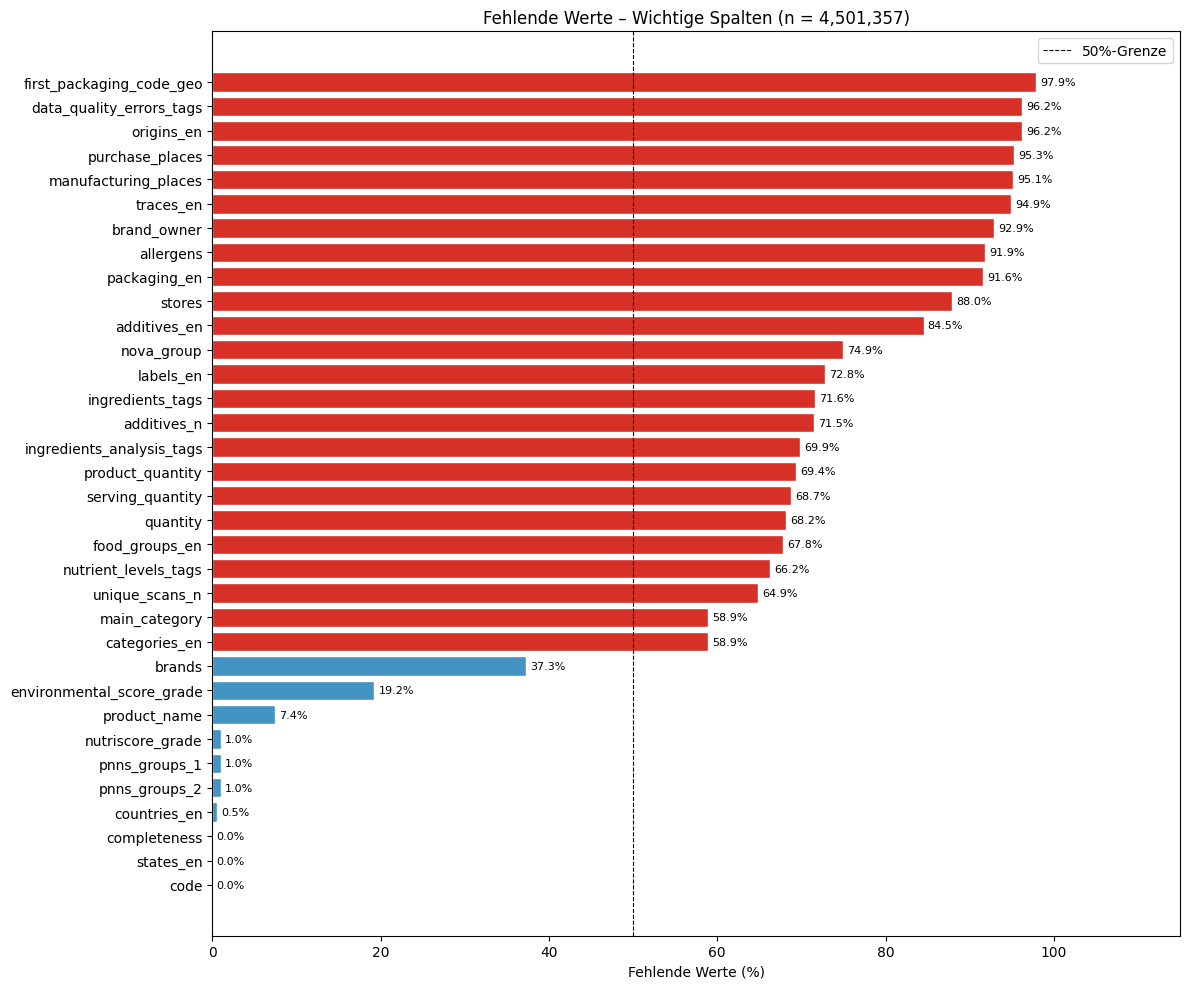

→ Grafik gespeichert: missing_values_wichtige_spalten.png


In [2]:
# ── FEHLENDE WERTE – WICHTIGE SPALTEN ────────────────────────
# Alle 34 Spalten aus Wichtige Spalten.txt
WICHTIGE_COLS = [
    "code", "product_name", "quantity", "packaging_en", "brands",
    "categories_en", "origins_en", "manufacturing_places", "labels_en",
    "first_packaging_code_geo", "purchase_places", "stores", "countries_en",
    "ingredients_tags", "ingredients_analysis_tags", "allergens", "traces_en",
    "serving_quantity", "additives_n", "additives_en", "nutriscore_grade",
    "nova_group", "pnns_groups_1", "pnns_groups_2", "food_groups_en",
    "states_en", "brand_owner", "environmental_score_grade",
    "nutrient_levels_tags", "product_quantity", "data_quality_errors_tags",
    "unique_scans_n", "completeness", "main_category",
]

print("⏳ Lade CSV mit wichtigen Spalten …")
df_wichtig = pd.read_csv(
    CSV_PATH,
    sep="\t",
    usecols=lambda c: c in WICHTIGE_COLS,
    low_memory=False,
    on_bad_lines="skip",
)
print(f"✅ Geladen: {df_wichtig.shape[0]:,} Zeilen  |  {df_wichtig.shape[1]} Spalten\n")

# Fehlende Werte berechnen
total = len(df_wichtig)
missing_pct = (df_wichtig.isnull().sum() / total * 100).sort_values(ascending=True)
missing_count = df_wichtig.isnull().sum().reindex(missing_pct.index)

print("Fehlende Werte pro Spalte:")
for col, pct, cnt in zip(missing_pct.index, missing_pct.values, missing_count.values):
    print(f"  {col:<35} {pct:5.1f}%  ({cnt:,} fehlend)")

# Visualisierung
colors = ["#d73027" if v > 50 else "#4393c3" for v in missing_pct]
fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor="white")
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)
ax.set_xlabel("Fehlende Werte (%)")
ax.set_title(f"Fehlende Werte – Wichtige Spalten (n = {total:,})")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50%-Grenze")
ax.set_xlim(0, 115)
ax.legend()
plt.tight_layout()
plt.savefig("missing_values_wichtige_spalten.png", dpi=150)
plt.show()
print("→ Grafik gespeichert: missing_values_wichtige_spalten.png")
